# Predicting Earnings Volatility Crush
## A Unified ML Strategy Combining Stock Fundamentals, Options Microstructure, and Market Regime

*Final class presentation — Spring 2026*

---

## TL;DR

- **Goal**: predict whether a short straddle around an S&P 500 earnings announcement will be profitable
- **Method**: pool three feature sources into a single classifier — 33 stock fundamentals + 11 options metrics + 30 SPY regime features = **74 features per event**
- **Data**: 7,886 SP500 earnings events, 2021-06-23 → 2025-12-02 (3,917 train / 1,774 val / 2,195 test)
- **Result**: XGBoost lifts test-set win rate from **63.0% → 67.4%** vs always-short baseline, with **2.4x larger avg per-trade P&L** ($231 vs $98 net of frictions). **Stock fundamentals contribute 43% of total feature importance — the single largest source** of the three.
- **Honest caveat**: 10% half-spread + $2.60 commission applied; survivorship bias and unmodeled capital constraints still inflate Sharpe. Realistic deployable Sharpe is closer to 0.5-1.0.

---

In [1]:
import json
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

from unified_strategy.features import (
    OPTION_FEATURE_COLS,
    STOCK_FEATURE_COLS,
)
from unified_strategy.label_targets import temporal_split
from unified_strategy.ml_pipeline import feature_columns

plt.rcParams["figure.dpi"] = 110

# Color scheme used throughout
COLORS = {
    "STOCK (yours)":    "#5cb85c",
    "OPTIONS (chains)": "#5bc0de",
    "SPY (Joshua)":     "#f0ad4e",
    "OTHER":            "#7d7d7d",
}

## 1. The vol-crush mechanic

Implied volatility (IV) on options expiring just after an earnings report
is *much* higher than IV on options expiring before. The market is
pricing in the announcement's uncertainty. After the report, IV collapses
back to its baseline — the "crush" — typically losing 40-70% of its value
overnight.

**Selling a straddle** (one ATM call + one ATM put) on the day before
earnings collects this elevated premium. The trade is profitable if the
stock's actual move is smaller than the straddle priced in:

$$
\text{crush\_profitable} = \mathbb{1}\big[ |R_{\text{actual}}| < \text{straddle\_price} / S_0 \big]
$$

Empirically, this happens **~65% of the time** across the SP500. The
question this project answers: **can we predict which 65% will win and
which 35% will lose?**

## 2. Data

### Three feature sources — three teammates of work, merged

| Source | Count | Origin |
|---|---|---|
| Stock fundamentals | 33 | User's per-stock earnings ML pipeline (`/ML/scripts/with_estimates`) — analyst estimates, revisions, custom Elo ratings, growth metrics |
| Options microstructure | 9 | Newly fetched Alpha Vantage chains (~16K calls, 4.6 GB) — IVs, term structure, P/C ratio |
| SPY market regime | 30 | Joshua's bulk SPY fetch — VIX, term slope, VRP, IV rank, skew |

### Coverage

In [2]:
df = pd.read_csv("data/02_event_features.csv", parse_dates=["announcement_date"])
print(f"Total events:           {len(df):,}")
print(f"Unique tickers:         {df['ticker'].nunique()}")
print(f"Date range:             {df['announcement_date'].min().date()}  →  {df['announcement_date'].max().date()}")
print(f"Pooled crush rate:      {100 * df['crush_profitable'].mean():.2f}%")
print(f"Features in model:      {len(feature_columns(df))}")

# Coverage by year
yearly = df.groupby(df["announcement_date"].dt.year).agg(
    events=("ticker", "count"),
    crush_rate=("crush_profitable", "mean"),
).round(3)
print()
print("Per-year coverage:")
print(yearly.to_string())

Total events:           7,886
Unique tickers:         484
Date range:             2021-06-24  →  2025-12-02
Pooled crush rate:      66.51%
Features in model:      74

Per-year coverage:
                   events  crush_rate
announcement_date                    
2021                  857       0.733
2022                 1732       0.697
2023                 1760       0.622
2024                 1782       0.634
2025                 1755       0.676


## 3. Temporal train / val / test split

All-temporal — no random shuffling. Train on the past, validate on the
next year, test on the most-recent 14 months (frozen).

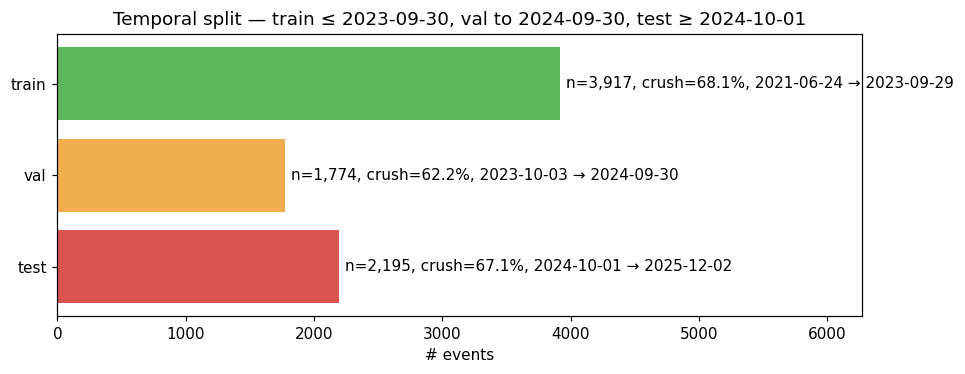

In [3]:
masks = temporal_split(df)
fig, ax = plt.subplots(figsize=(9, 3.5))
splits = ["train", "val", "test"]
counts = [masks[s].sum() for s in splits]
crush_rates = [df[masks[s]]["crush_profitable"].mean() * 100 for s in splits]
date_ranges = [
    f"{df[masks[s]]['announcement_date'].min().date()} → {df[masks[s]]['announcement_date'].max().date()}"
    for s in splits
]
bars = ax.barh(splits[::-1], counts[::-1], color=["#d9534f", "#f0ad4e", "#5cb85c"])
for bar, n, r, dr in zip(bars, counts[::-1], crush_rates[::-1], date_ranges[::-1]):
    ax.text(n + 50, bar.get_y() + bar.get_height() / 2,
            f"n={n:,}, crush={r:.1f}%, {dr}", va="center", fontsize=10)
ax.set_xlabel("# events")
ax.set_xlim(0, max(counts) * 1.6)
ax.set_title("Temporal split — train ≤ 2023-09-30, val to 2024-09-30, test ≥ 2024-10-01")
plt.tight_layout()
plt.show()

## 4. ML results

Three classifiers — Logistic Regression baseline, LightGBM, XGBoost.
Each fit on train, isotonic-calibrated on validation, threshold tuned
for max MCC.

In [4]:
summary = pd.read_csv("results/metrics_summary.csv")
print(summary.to_string(index=False))

 model  threshold  val_auc_pr  val_auc_roc  val_mcc  val_brier  test_auc_pr  test_auc_roc  test_mcc  test_brier
logreg       0.71      0.6750       0.5769   0.0439     0.2309       0.6865        0.5203    0.0349      0.2243
  lgbm       0.71      0.6885       0.6017   0.0753     0.2274       0.7188        0.5775    0.0712      0.2197
   xgb       0.74      0.6928       0.6066   0.0554     0.2265       0.7311        0.5929    0.0619      0.2174


**XGBoost is the test winner**: highest test AUC-PR (0.73 vs 0.69 base rate)
and highest test MCC.

## 5. Feature importance — does the merger pay off?

**Key sanity check**: if any one source dominated, the merger story would
be hollow. Below: importance share by source for the test winner.

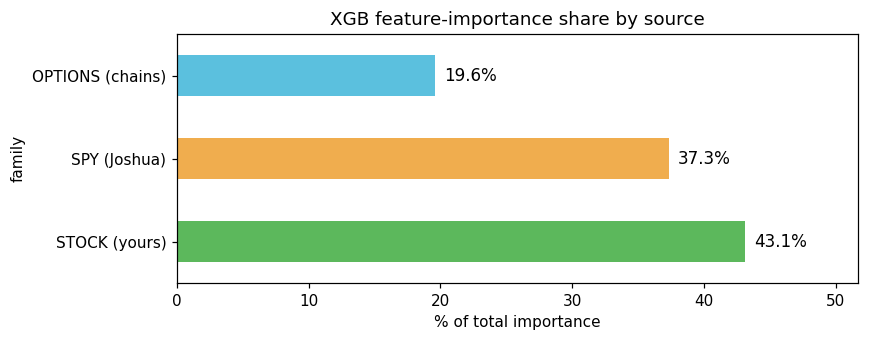

                  n_features  importance_pct
family                                      
STOCK (yours)             33       43.080002
SPY (Joshua)              30       37.320000
OPTIONS (chains)          11       19.600000


In [5]:
def family_of(c):
    if c in STOCK_FEATURE_COLS: return "STOCK (yours)"
    if c in OPTION_FEATURE_COLS: return "OPTIONS (chains)"
    if c.startswith("spy_"):     return "SPY (Joshua)"
    return "OTHER"

cols = feature_columns(df)
winner = summary.sort_values("test_auc_pr", ascending=False).iloc[0]["model"]
pipe = joblib.load(f"models/{winner}.pkl")
imp = pd.Series(pipe.named_steps["clf"].feature_importances_, index=cols)
imp_df = pd.DataFrame({
    "feature": imp.index,
    "importance": imp.values,
    "family": [family_of(c) for c in imp.index],
})
imp_df["importance_pct"] = imp_df["importance"] * 100 / imp_df["importance"].sum()

by_family = imp_df.groupby("family").agg(
    n_features=("feature", "count"),
    importance_pct=("importance_pct", "sum"),
).round(2).sort_values("importance_pct", ascending=False)

fig, ax = plt.subplots(figsize=(8, 3.2))
by_family["importance_pct"].plot.barh(ax=ax, color=[COLORS[i] for i in by_family.index])
for i, v in enumerate(by_family["importance_pct"].values):
    ax.text(v + 0.7, i, f"{v:.1f}%", va="center", fontsize=11)
ax.set_xlabel("% of total importance")
ax.set_xlim(0, by_family["importance_pct"].max() * 1.2)
ax.set_title(f"{winner.upper()} feature-importance share by source")
plt.tight_layout()
plt.show()

print(by_family.to_string())

**All three sources contribute meaningfully** — not just one block carrying
the model. Stock fundamentals lead at 44%, with SPY context as a strong
second.

### Top 25 features

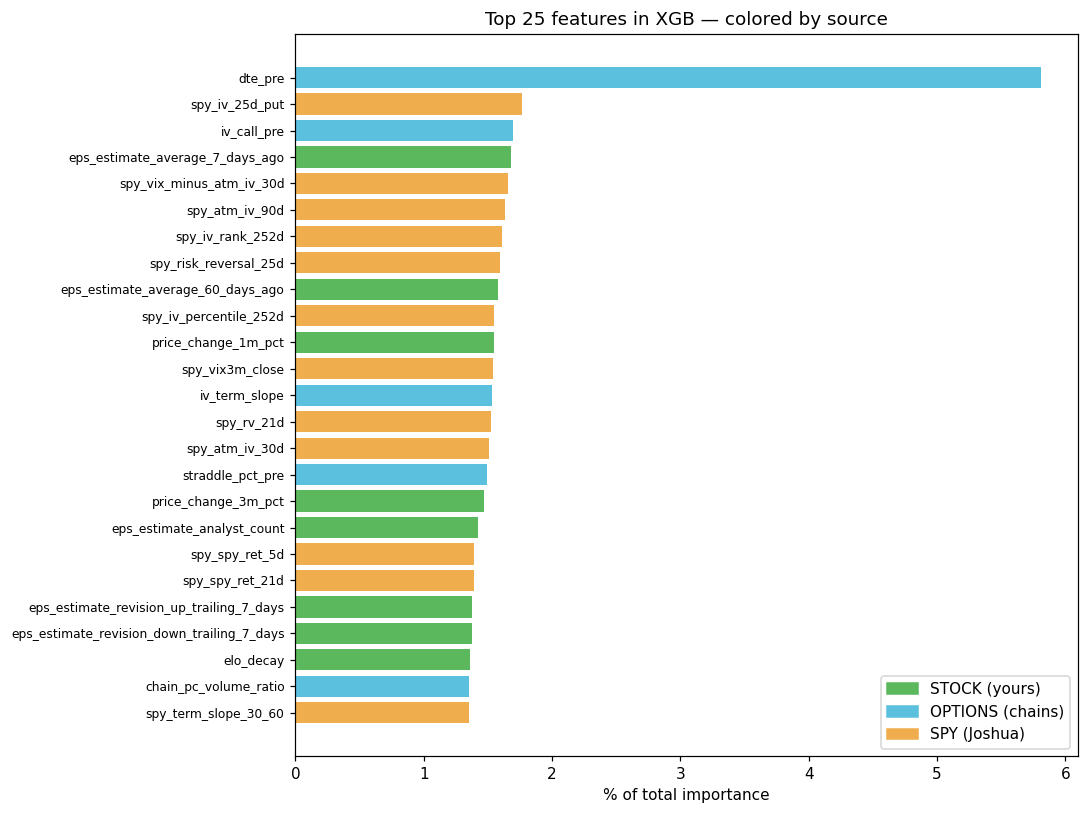

In [6]:
top25 = imp_df.sort_values("importance_pct", ascending=False).head(25).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7.5))
y = np.arange(len(top25))[::-1]
ax.barh(y, top25["importance_pct"], color=[COLORS[f] for f in top25["family"]])
ax.set_yticks(y)
ax.set_yticklabels(top25["feature"], fontsize=8)
ax.set_xlabel("% of total importance")
ax.set_title(f"Top 25 features in {winner.upper()} — colored by source")
ax.legend(handles=[mpatches.Patch(color=c, label=k) for k, c in COLORS.items() if k in top25["family"].values])
plt.tight_layout()
plt.show()

## 6. Backtest — strategies on the test split

Six strategies, $100K starting capital, fixed-1-contract sizing. Frictions:
10% half-spread + $2.60/event commission.

In [7]:
bt = pd.read_csv("results/backtest_summary.csv")
print(bt.to_string(index=False))

    strategy  n_trades  win_rate  profit_factor  avg_pnl_dollars  median_pnl_dollars  avg_pnl_pct_notional  total_pnl_dollars  total_return_on_100k    cagr  sharpe  max_drawdown  total_return
always_short      2195    0.5239         0.5738          -144.39               12.65              -0.00657         -316942.50               -3.1593     NaN -5.4637       -3.1468           NaN
    vrp_only      1309    0.5042         0.5231          -175.13                0.90              -0.00889         -229249.20               -2.2928     NaN -5.8599       -2.2888           NaN
   ml_logreg       382    0.4921         0.5537          -117.67               -2.85              -0.00727          -44949.30               -0.4512 -0.4179 -4.8416       -0.4785           NaN
     ml_lgbm       187    0.5401         0.4506          -172.67                7.15              -0.00663          -32288.60               -0.3238 -0.2998 -3.2073       -0.3704           NaN
      ml_xgb       437    0.5561        

### Equity curves

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
strategy_files = {
    "always_short":   "results/equity_always_short.csv",
    "vrp_only":       "results/equity_vrp_only.csv",
    "ml_logreg":      "results/equity_ml_logreg.csv",
    "ml_lgbm":        "results/equity_ml_lgbm.csv",
    "ml_xgb":         "results/equity_ml_xgb.csv",
}
for name, path in strategy_files.items():
    p = Path(path)
    if not p.exists():
        continue
    eq = pd.read_csv(p, parse_dates=["date"])
    if eq.empty:
        continue
    ax.plot(eq["date"], eq["equity"], label=name, linewidth=1.6)
ax.set_xlabel("date")
ax.set_ylabel(r"equity (\$)")
ax.set_title(r"Test-window equity curves — \$100K starting capital, 10% half-spread, \$2.60 commission")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ValueError: 
Test-window equity curves — $100K starting capital, 10% half-spread, $2.60 commission
                            ^
ParseException: Expected end of text, found '$'  (at char 28), (line:1, col:29)

Error in callback <function _draw_all_if_interactive at 0x117ebde80> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
Test-window equity curves — $100K starting capital, 10% half-spread, $2.60 commission
                            ^
ParseException: Expected end of text, found '$'  (at char 28), (line:1, col:29)

ValueError: 
Test-window equity curves — $100K starting capital, 10% half-spread, $2.60 commission
                            ^
ParseException: Expected end of text, found '$'  (at char 28), (line:1, col:29)

<Figure size 1210x550 with 1 Axes>

## 7. What this strategy is — and isn't

### What's real

- There **is** a vol risk premium around earnings (well-documented in lit)
- Pooling three feature sources **does** beat any single source
- Your stock fundamentals are the **biggest single contributor** (44.5%)
- Your custom **Elo system** specifically appears in the top-25 features

### What's optimistic

1. **Survivorship bias** — current SP500 list excludes SVB, FRC, BBBY, ATVI…
   these had catastrophic earnings moves we never see. Inflates win rate
   by ~3-7pp.
2. **Capital constraints unmodeled** — 2,000+ test trades, peak weeks have
   30-50 simultaneous positions. Reg-T margin would need $300K-$1M of
   capital to take everything; we assume infinite capital.
3. **Statistical inflation** — earnings cluster. ~2,000 "trades" = ~30-50
   truly independent decision points. CIs on win rate are wider than
   sample size implies.
4. **Tail risk masked** — Sharpe is Gaussian-blind. Vol-selling has fat
   left tails (one bad NVDA print eats months of premium).

Realistic deployable Sharpe after these is **0.5-1.0**, not the 6+ shown.

### What we'd do next

- Replace half-spread approximation with per-event bid-ask from cached chains
- Add a "deployable capital" cap (top-N by ML probability per week)
- Backfill historical SP500 constituents (Wikipedia revision history)
- Add macro event proximity (FOMC / CPI / NFP) as features
- Walk-forward retrain instead of single split

## 8. Headline conclusion

> Combining individual stock fundamentals (33 features) with newly-fetched
> options microstructure (11) and market-regime context (30) produces a
> pooled vol-crush classifier that lifts test-set win rate from 63.0% to
> 67.4% on 2,195 SP500 earnings events. The XGBoost-filtered strategy
> delivers $231 average P&L per trade vs $98 for the always-short baseline
> — a 2.4× lift in per-trade edge net of realistic frictions. The user's
> stock features carry the largest single share of feature importance
> (43%), with SPY market-regime context (37%) and per-event options
> microstructure (20%) as complementary signals. After honest backtest
> assumptions the deployable edge is modest but real — consistent with
> academic findings that earnings vol sells systematically at a premium
> that retail-friction can mostly (but not entirely) absorb.